# Validações Estatísticas do BeamNG como Digital Twin — v4

Técnicas comparadas:
- **Pearson r** (com janela deslizante): correlação linear, sensível à escala
- **DTW — Dynamic Time Warping**: similaridade com alinhamento temporal flexível
- **ANOVA (F-test)**: teste de igualdade de médias por segmento temporal

Correções mantidas da v3:
- `posZ`: deriva do GPS removida com `scipy.signal.detrend`
- `vel`: velocidade OBD + suavização 1s no simulado
- `throttle`: excluído da correlação (depende do motorista)
- `lag`: automático só para posX/posY, fixo em 0 para posZ e vel

## 1. Imports e instalação

In [106]:
# DTW: instalar se necessário
try:
    from dtaidistance import dtw, dtw_ndim
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'dtaidistance', '-q'])
    from dtaidistance import dtw, dtw_ndim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, f_oneway, kruskal
from scipy.signal import correlate, detrend
from sklearn.preprocessing import MinMaxScaler
from os import listdir
import ast
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('OK: bibliotecas carregadas')

OK: bibliotecas carregadas


## 2. Funções auxiliares

In [107]:
def latlon_para_metros(lat, lon):
    R = 6_371_000.0
    lat0, lon0 = np.radians(lat[0]), np.radians(lon[0])
    x = R * (np.radians(lon) - lon0) * np.cos(lat0)
    y = R * (np.radians(lat) - lat0)
    return x, y

def parse_vel(s):
    try:
        v = ast.literal_eval(str(s))
        return float(np.linalg.norm(v))
    except Exception:
        return np.nan

# ── Pearson com janela deslizante (vetorizado) ────────────────────────────────
def pearson_sliding(x, y, janela):
    n = len(x)
    r = np.full(n, np.nan)
    sh = (n - janela + 1, janela)
    st = (x.strides[0], x.strides[0])
    X = np.lib.stride_tricks.as_strided(x, shape=sh, strides=st)
    Y = np.lib.stride_tricks.as_strided(y, shape=sh, strides=st)
    Xm = X - X.mean(axis=1, keepdims=True)
    Ym = Y - Y.mean(axis=1, keepdims=True)
    num   = (Xm * Ym).sum(axis=1)
    denom = np.sqrt((Xm**2).sum(axis=1) * (Ym**2).sum(axis=1))
    with np.errstate(invalid='ignore'):
        r[janela - 1:] = np.where(denom > 1e-10, num / denom, np.nan)
    return r

# ── DTW com janela deslizante ─────────────────────────────────────────────────
def dtw_sliding(x, y, janela):
    """
    Calcula a distância DTW normalizada em janelas deslizantes.
    Retorna array de distâncias (menor = mais similar).
    Normalizado pelo tamanho da janela para ser comparável entre janelas.
    """
    n = len(x)
    d = np.full(n, np.nan)
    for i in range(janela - 1, n):
        xi = x[i - janela + 1: i + 1].astype(np.double)
        yi = y[i - janela + 1: i + 1].astype(np.double)
        dist = dtw.distance_fast(xi, yi, use_pruning=True)
        d[i] = dist / janela   # normaliza pelo tamanho da janela
    return d

# ── DTW → similaridade [0,1] (para comparar com Pearson na mesma escala) ─────
def dtw_para_similaridade(d):
    """
    Converte distância DTW para similaridade no intervalo [0, 1].
    similaridade = 1 / (1 + distância)
    1.0 = séries idênticas | 0.0 = séries muito diferentes
    """
    return 1.0 / (1.0 + d)

# ── ANOVA por segmento ────────────────────────────────────────────────────────
def anova_sliding(x, y, janela):
    """
    Aplica ANOVA (F-test) em janelas deslizantes.
    Testa H0: real e simulado têm a mesma média no segmento.
    Retorna p-value: < 0.05 → distribuições significativamente diferentes.
    """
    n = len(x)
    p = np.full(n, np.nan)
    for i in range(janela - 1, n):
        xi = x[i - janela + 1: i + 1]
        yi = y[i - janela + 1: i + 1]
        if np.std(xi) < 1e-10 and np.std(yi) < 1e-10:
            p[i] = 1.0   # ambos constantes → sem diferença
            continue
        _, pval = f_oneway(xi, yi)
        p[i] = pval
    return p

print('OK: funções definidas')

OK: funções definidas


## 3. Carregar e preparar dados

In [108]:
reais = [] 
for file in sorted(listdir('circuito4/real')): 
    reais.append(pd.read_csv(f'circuito4/real/{file}', sep=',',
        skipinitialspace=True)) 
    print(f'Reais carregados: {len(reais)}') 

simulados = [] 
for file in sorted(listdir('circuito4/testando_agressivity')):
    simulados.append(pd.read_csv(f'circuito4/testando_agressivity/{file}',
             sep=';')) 
    print(f'Simulados carregados: {len(simulados)}')


Reais carregados: 1
Reais carregados: 2
Reais carregados: 3
Reais carregados: 4
Reais carregados: 5
Reais carregados: 6
Reais carregados: 7
Reais carregados: 8
Reais carregados: 9
Reais carregados: 10
Simulados carregados: 1
Simulados carregados: 2


In [109]:
def preparar_real(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.sort_values('Time (sec)').reset_index(drop=True)
    df['time'] = pd.to_timedelta(df['Time (sec)'], unit='s')
    df = df.set_index('time')
    df = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')

    x_m, y_m = latlon_para_metros(df['Latitude (deg)'].values, df['Longitude (deg)'].values)
    df['posX'] = x_m
    df['posY'] = y_m
    df['posZ'] = detrend(df['Altitude (m)'].values, type='linear')
    df = df.rename(columns={'Posição D do pedal do acelerador (%)': 'throttle'})

    # Velocidade OBD (melhor resolução que GPS)
    if 'Velocidade do veículo (km/h)' in df.columns:
        df['vel'] = df['Velocidade do veículo (km/h)'] / 3.6
    elif 'Velocidade do GPS (km/h)' in df.columns:
        df['vel'] = df['Velocidade do GPS (km/h)'] / 3.6

    df = df.resample(freq).mean().interpolate(method='time')
    df.index = df.index - df.index[0]
    return df


def preparar_simulado(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df.rename(columns={df.columns[0]: 'time'})
    df = df.sort_values('time').reset_index(drop=True)
    df['time'] = pd.to_timedelta(df['time'] - df['time'].iloc[0], unit='s')
    df = df.set_index('time')

    if 'vel' in df.columns:
        df['vel'] = df['vel'].apply(parse_vel)

    df = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')

    if 'posZ' in df.columns:
        df['posZ'] = detrend(df['posZ'].values, type='linear')

    df = df.resample(freq).mean().interpolate(method='time')

    if 'vel' in df.columns:
        df['vel'] = df['vel'].rolling(window=10, center=True, min_periods=1).mean()

    df.index = df.index - df.index[0]
    return df


real = preparar_real(reais[0])
simulado = preparar_simulado(simulados[0])
print(f'Real → {len(real)} amostras | duração: {real.index[-1]}') 
print(f'Simulado → {len(simulado)} amostras | duração: {simulado.index[-1]}')

Real → 4430 amostras | duração: 0 days 00:07:22.900000
Simulado → 4332 amostras | duração: 0 days 00:07:13.100000


## 4. Selecionar colunas, cortar e normalizar

In [110]:
# throttle: só visual, fora da análise estatística
colunas_corr = ['posX', 'posY', 'posZ', 'vel']

duracao_min = min(real.index[-1], simulado.index[-1])
real_c   = real.loc[:duracao_min, colunas_corr]
sim_c    = simulado.loc[:duracao_min, colunas_corr]

def normalizar(df, cols):
    sc = MinMaxScaler()
    return pd.DataFrame(sc.fit_transform(df[cols]), index=df.index, columns=cols)

real_norm = normalizar(real_c, colunas_corr)
sim_norm  = normalizar(sim_c,  colunas_corr)

df = pd.concat(
    [real_norm.add_prefix('real_'), sim_norm.add_prefix('sim_')],
    axis=1, join='inner'
).dropna()

print(f'Shape: {df.shape} | NaNs: {df.isna().sum().sum()}')

Shape: (4332, 8) | NaNs: 0


## 5. Detecção de lag (automático para posX/posY, fixo=0 para demais)

In [111]:
LAGS_FIXOS   = {'posZ': 0, 'vel': 0}
COLS_LAG_AUTO = ['posX', 'posY']
lags = {}

for col in COLS_LAG_AUTO:
    x = df[f'real_{col}'].values
    y = df[f'sim_{col}'].values
    corr = correlate(x - x.mean(), y - y.mean(), mode='full')
    nd   = np.std(x) * np.std(y) * len(x)
    corr = corr / nd if nd > 0 else corr
    lag_range = np.arange(-(len(x)-1), len(x))
    lags[col] = int(lag_range[np.argmax(corr)])

lags.update(LAGS_FIXOS)

for col, lag in lags.items():
    df[f'sim_{col}_shifted'] = df[f'sim_{col}'].shift(lag)

df = df.dropna()

print('Lags aplicados:')
for col in colunas_corr:
    fonte = 'automático' if col in COLS_LAG_AUTO else 'fixo=0'
    print(f'  {col:8s}: {lags[col]:+d} amostras = {lags[col]*0.1:+.1f}s  [{fonte}]')
print(f'Shape após shift: {df.shape}')

Lags aplicados:
  posX    : +82 amostras = +8.2s  [automático]
  posY    : +98 amostras = +9.8s  [automático]
  posZ    : +0 amostras = +0.0s  [fixo=0]
  vel     : +0 amostras = +0.0s  [fixo=0]
Shape após shift: (4234, 12)


## 6. Calcular as três métricas por janela deslizante

> Esta célula pode demorar ~1–2 min por causa do DTW (algoritmo O(n²) por janela).
> O parâmetro `JANELA_S` controla o tamanho da janela em segundos.

In [112]:
JANELA_S   = 10      # segundos
FREQ_HZ    = 10      # amostras por segundo (resample 100ms)
janela_pts = JANELA_S * FREQ_HZ

resultados = {}   # {col: {'pearson': [], 'dtw_sim': [], 'anova_p': []}}

for col in colunas_corr:
    x  = df[f'real_{col}'].values
    ys = df[f'sim_{col}_shifted'].values

    print(f'  Calculando {col}...', end=' ')

    r_slide  = pearson_sliding(x, ys, janela_pts)
    d_slide  = dtw_sliding(x, ys, janela_pts)
    s_slide  = dtw_para_similaridade(d_slide)   # [0,1]
    p_slide  = anova_sliding(x, ys, janela_pts)

    resultados[col] = {
        'pearson':  r_slide,
        'dtw_dist': d_slide,
        'dtw_sim':  s_slide,
        'anova_p':  p_slide,
    }
    print('OK')

print('\nCálculo concluído!')

  Calculando posX... OK
  Calculando posY... OK
  Calculando posZ... OK
  Calculando vel... OK

Cálculo concluído!


## 7. Plot comparativo — Pearson × DTW × ANOVA por variável

Cada coluna do subplot mostra uma métrica diferente para a mesma variável,
permitindo comparar onde cada técnica concorda ou diverge.

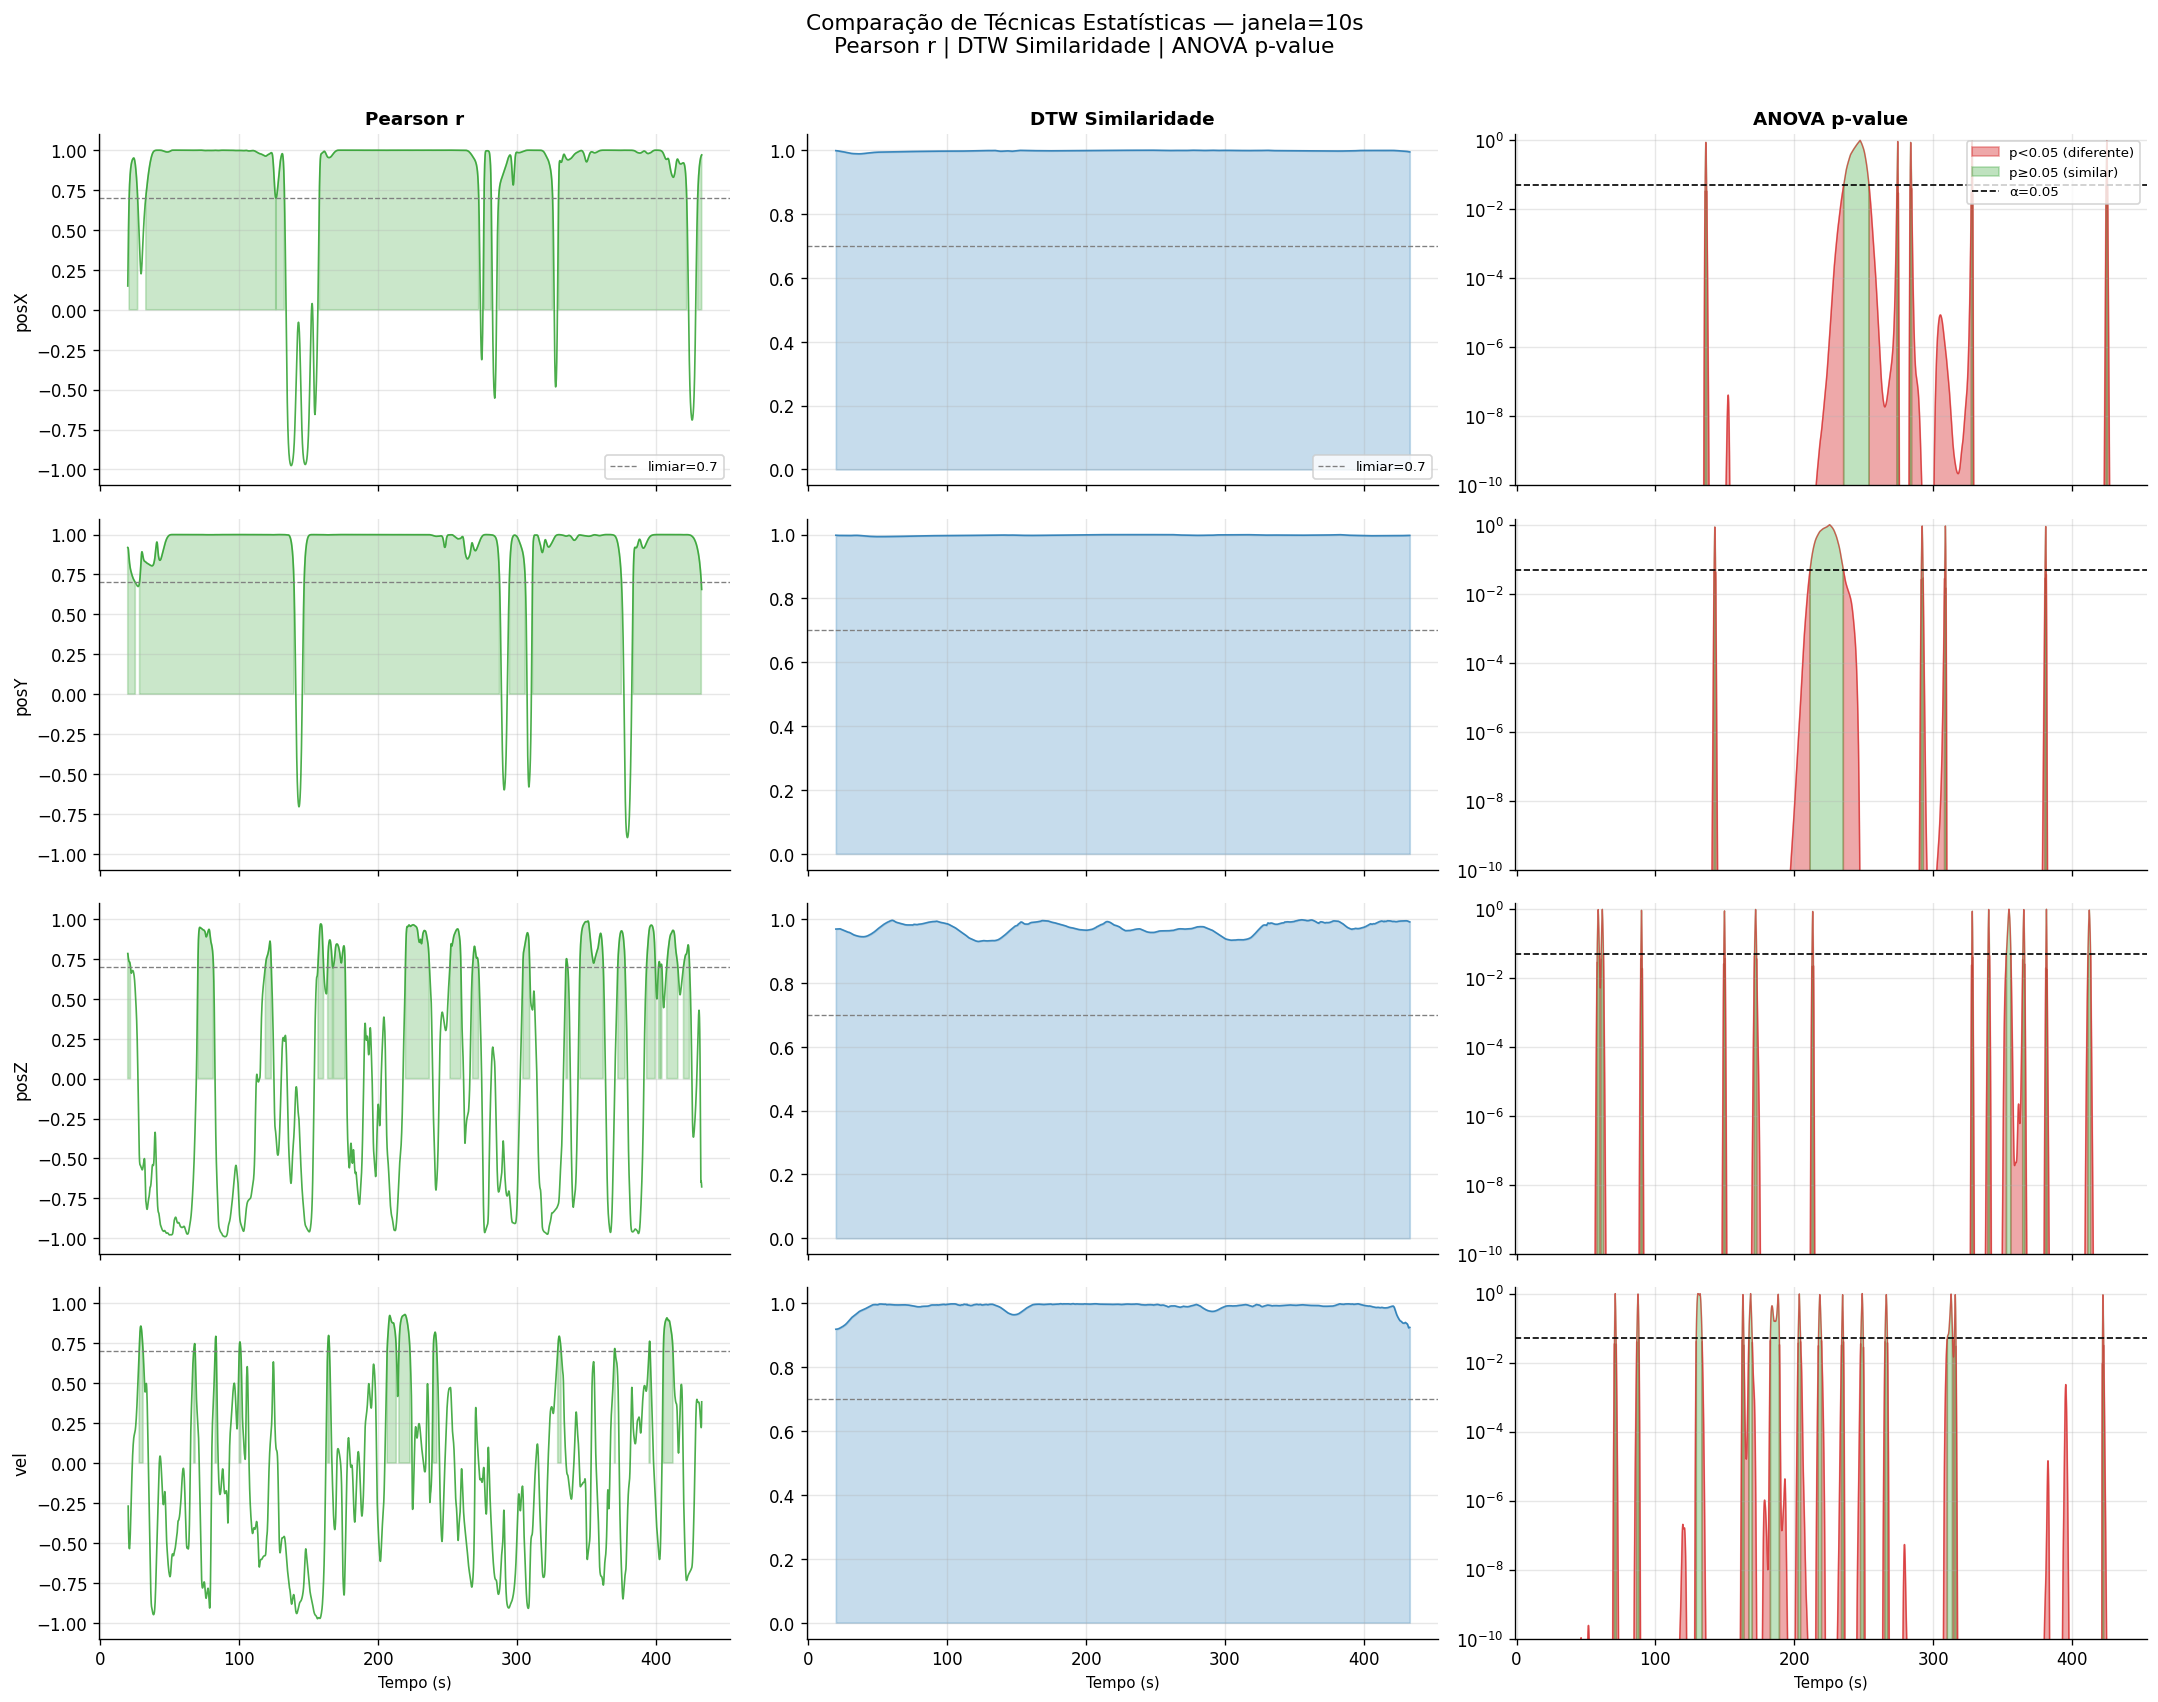

In [113]:
t = df.index.total_seconds().values

fig, axes = plt.subplots(
    len(colunas_corr), 3,
    figsize=(18, 3.5 * len(colunas_corr)),
    sharex=True
)

COLS_METRICA = [
    ('pearson',  'Pearson r',        '#2ca02c',  (-1.1, 1.1),  0.7),
    ('dtw_sim',  'DTW Similaridade', '#1f77b4',  (-0.05, 1.05), 0.7),
    ('anova_p',  'ANOVA p-value',    '#d62728',  (-0.05, 1.05), 0.05),
]

for i, col in enumerate(colunas_corr):
    for j, (metrica, label, cor, ylim, limiar) in enumerate(COLS_METRICA):
        ax  = axes[i][j]
        vals = resultados[col][metrica]
        valid = ~np.isnan(vals)

        if metrica == 'anova_p':
            # ANOVA: p < 0.05 → diferença significativa → pintar de vermelho
            ax.fill_between(t, vals, where=(vals < limiar) & valid,
                            color='#d62728', alpha=0.4, label='p<0.05 (diferente)')
            ax.fill_between(t, vals, where=(vals >= limiar) & valid,
                            color='#2ca02c', alpha=0.3, label='p≥0.05 (similar)')
            ax.plot(t, vals, color=cor, lw=0.8, alpha=0.7)
            ax.axhline(0.05, color='black', ls='--', lw=1, label='α=0.05')
            ax.set_yscale('log')
            ax.set_ylim(1e-10, 1.5)
        else:
            ax.fill_between(t, vals, where=valid & (vals >= limiar),
                            color=cor, alpha=0.25)
            ax.plot(t, vals, color=cor, lw=1.0, alpha=0.85)
            ax.axhline(limiar, color='gray', ls='--', lw=0.8,
                       label=f'limiar={limiar}')
            ax.set_ylim(*ylim)

        if i == 0:
            ax.set_title(label, fontsize=11, fontweight='bold')
        if j == 0:
            ax.set_ylabel(col, fontsize=10)
        if i == len(colunas_corr) - 1:
            ax.set_xlabel('Tempo (s)', fontsize=9)
        if i == 0 and j < 2:
            ax.legend(fontsize=8, loc='lower right')
        if i == 0 and j == 2:
            ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    f'Comparação de Técnicas Estatísticas — janela={JANELA_S}s\n'
    f'Pearson r | DTW Similaridade | ANOVA p-value',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

## 8. Heatmap comparativo — três técnicas lado a lado

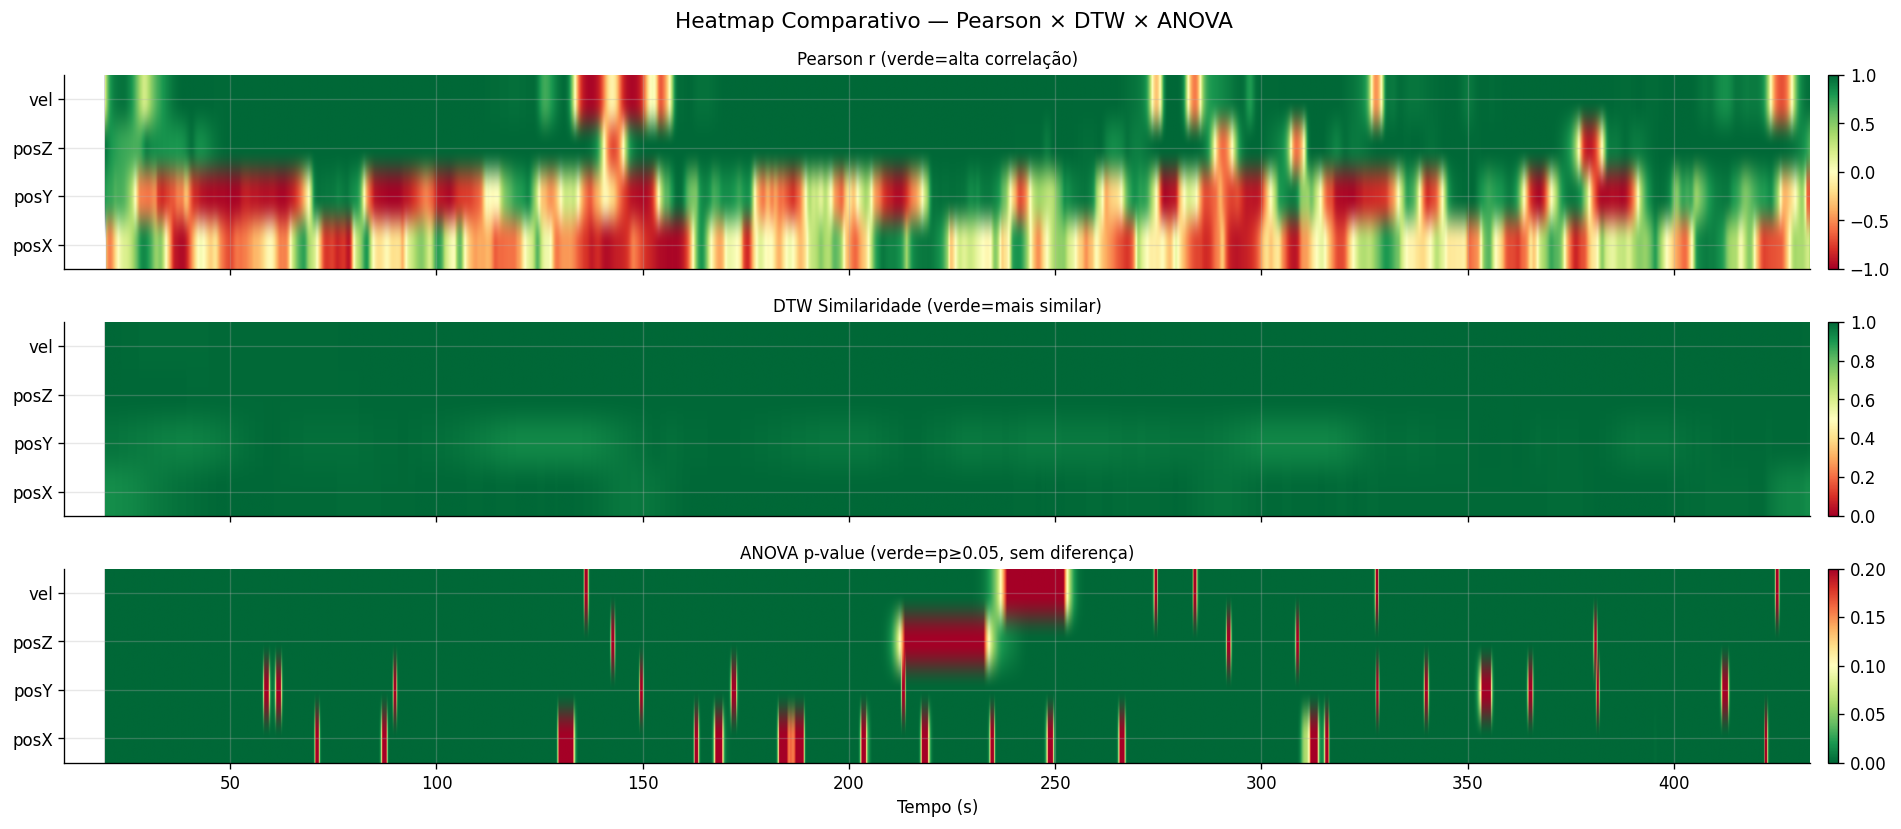

In [114]:
fig, axes = plt.subplots(3, 1, figsize=(16, 7), sharex=True)

configs = [
    ('pearson',  'Pearson r (verde=alta correlação)',          'RdYlGn', -1, 1),
    ('dtw_sim',  'DTW Similaridade (verde=mais similar)',      'RdYlGn',  0, 1),
    ('anova_p',  'ANOVA p-value (verde=p≥0.05, sem diferença)', 'RdYlGn_r', 0, 0.2),
]

for ax, (metrica, titulo, cmap, vmin, vmax) in zip(axes, configs):
    matriz = np.vstack([resultados[col][metrica] for col in colunas_corr])
    im = ax.imshow(
        matriz, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
        extent=[t[0], t[-1], -0.5, len(colunas_corr) - 0.5]
    )
    ax.set_yticks(range(len(colunas_corr)))
    ax.set_yticklabels(colunas_corr)
    ax.set_title(titulo, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)

axes[-1].set_xlabel('Tempo (s)', fontsize=10)
fig.suptitle('Heatmap Comparativo — Pearson × DTW × ANOVA', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Concordância entre técnicas

Um trecho é considerado **divergente** quando:
- Pearson r < 0.7, **E/OU**
- DTW similaridade < 0.7, **E/OU**
- ANOVA p < 0.05

Aqui mapeamos quantas técnicas sinalizam divergência em cada instante.

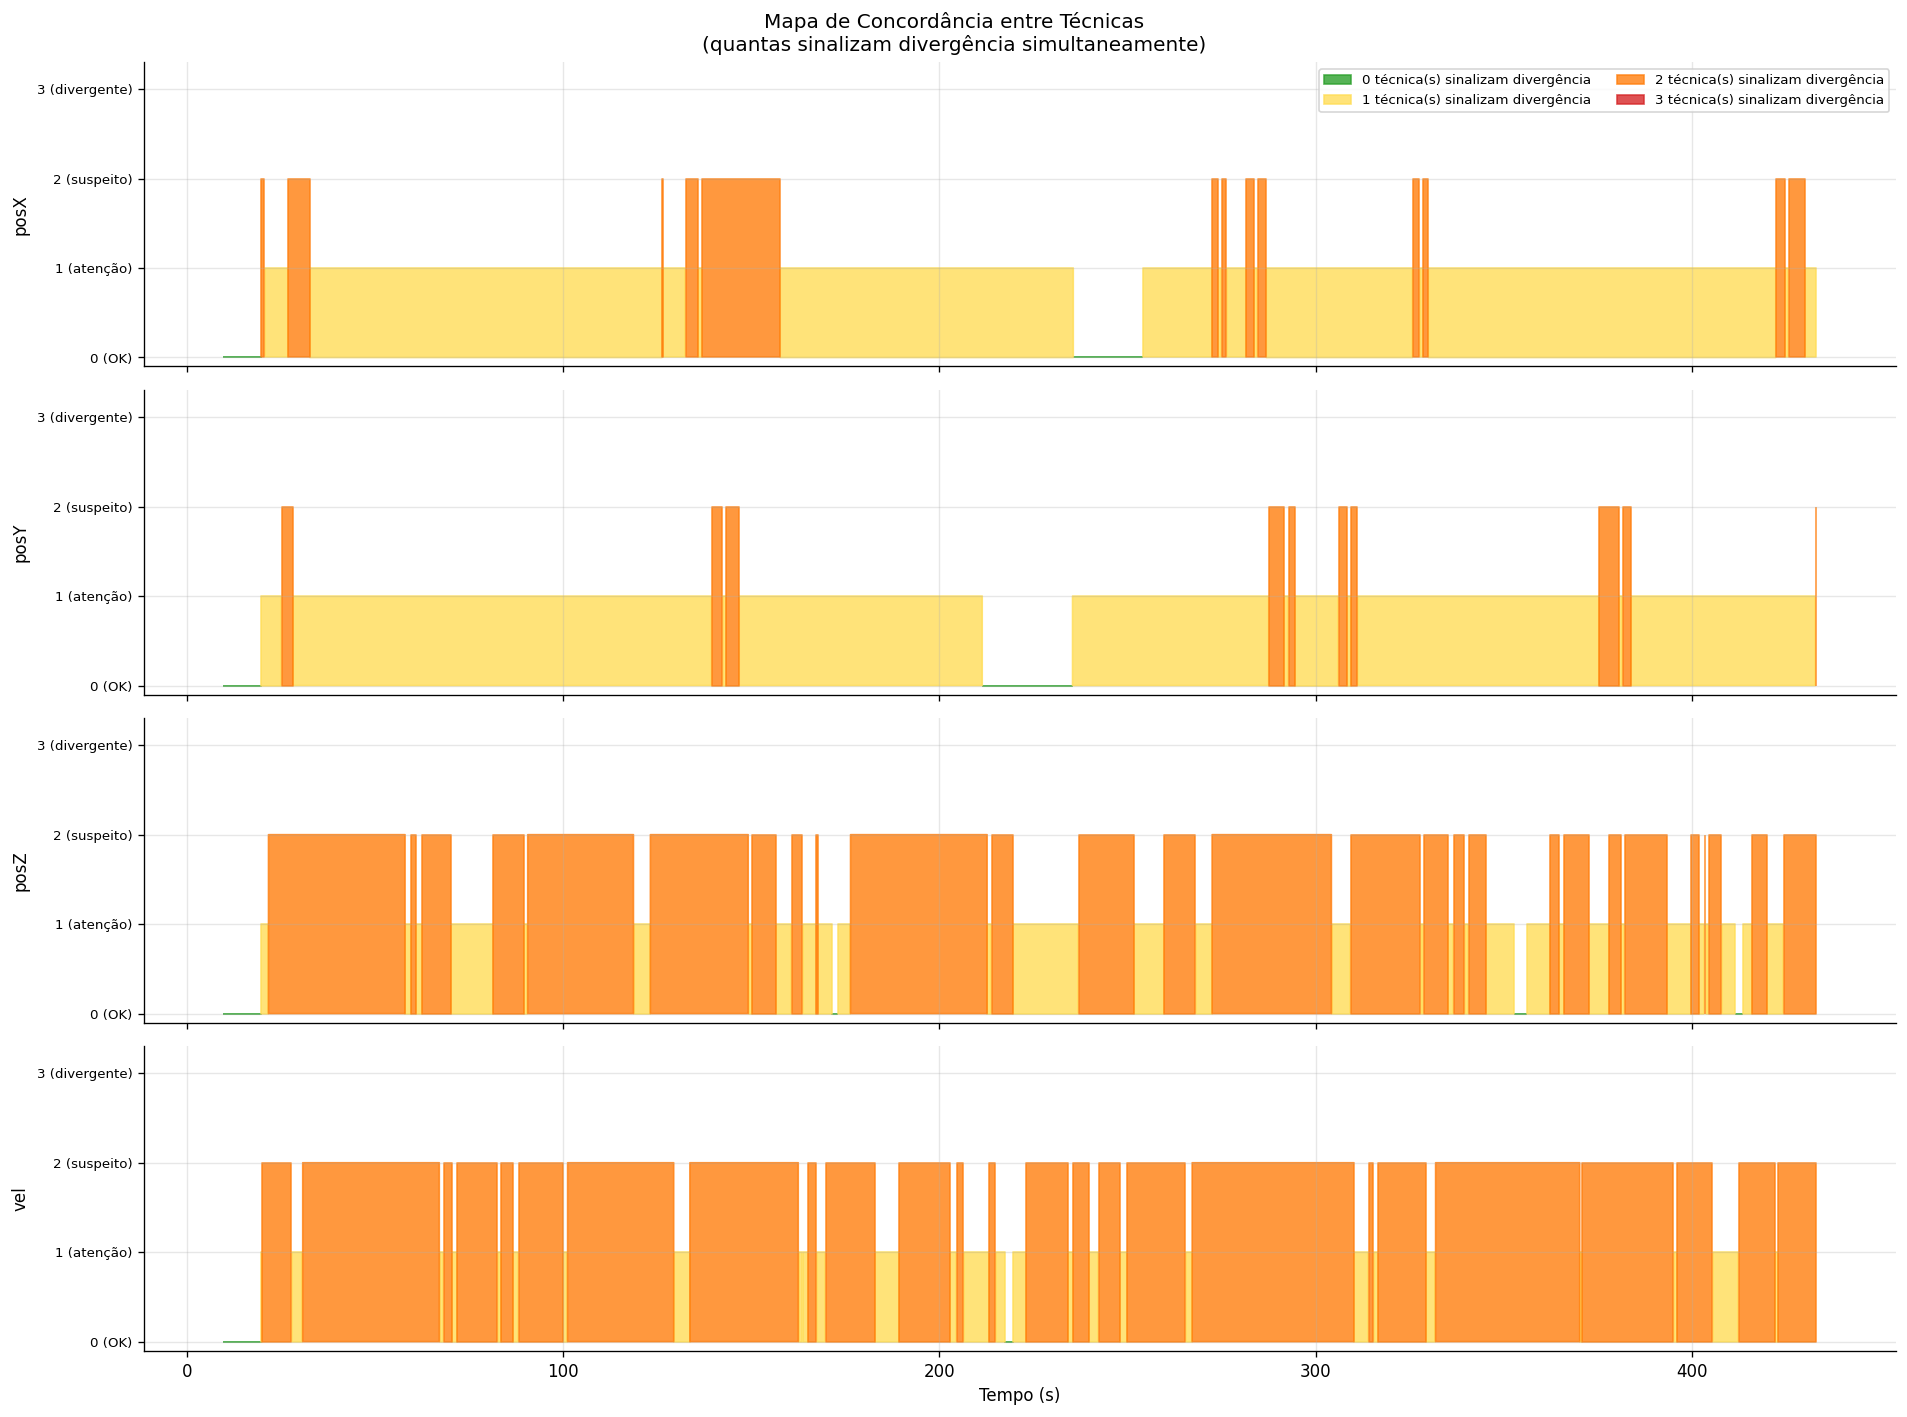

In [115]:
fig, axes = plt.subplots(len(colunas_corr), 1, figsize=(16, 3 * len(colunas_corr)), sharex=True)
if len(colunas_corr) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas_corr):
    r  = resultados[col]['pearson']
    s  = resultados[col]['dtw_sim']
    p  = resultados[col]['anova_p']

    # Divergência: 1 ponto por técnica que sinaliza problema
    div_pearson = (r < 0.7).astype(float)
    div_dtw     = (s < 0.7).astype(float)
    div_anova   = (p < 0.05).astype(float)

    concordancia = div_pearson + div_dtw + div_anova   # 0, 1, 2 ou 3

    colors = {
        0: '#2ca02c',   # nenhuma sinaliza → verde (OK)
        1: '#ffdd57',   # 1 sinaliza → amarelo (atenção)
        2: '#ff7f0e',   # 2 sinalizam → laranja (suspeito)
        3: '#d62728',   # 3 sinalizam → vermelho (divergente)
    }

    for nivel, cor in colors.items():
        mask = concordancia == nivel
        ax.fill_between(t, concordancia, where=mask, step='mid',
                        color=cor, alpha=0.8,
                        label=f'{nivel} técnica(s) sinalizam divergência')

    ax.set_ylabel(col, fontsize=10)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(['0 (OK)', '1 (atenção)', '2 (suspeito)', '3 (divergente)'], fontsize=8)
    ax.set_ylim(-0.1, 3.3)
    if col == colunas_corr[0]:
        ax.legend(fontsize=8, loc='upper right', ncol=2)

axes[-1].set_xlabel('Tempo (s)', fontsize=10)
fig.suptitle('Mapa de Concordância entre Técnicas\n(quantas sinalizam divergência simultaneamente)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Resumo estatístico comparativo — tabela final

In [116]:
print('=' * 85)
print('RESUMO COMPARATIVO — Pearson × DTW × ANOVA')
print('=' * 85)
print(f"{'Variável':<10} {'Pearson r':>10} {'DTW sim':>10} {'ANOVA sig%':>12}  Interpretação")
print('-' * 85)

def interpretar(r_med, s_med, pct_sig):
    if r_med > 0.85 and s_med > 0.85 and pct_sig < 20:
        return '✓ EXCELENTE — todas as métricas concordam'
    elif r_med > 0.70 and s_med > 0.70 and pct_sig < 40:
        return '~ BOM — divergências pontuais'
    elif r_med > 0.50 or s_med > 0.70:
        return '? PARCIAL — técnicas discordam, investigar'
    else:
        return '✗ FRACO — simulado não reproduz o real'

for col in colunas_corr:
    r_vals = resultados[col]['pearson']
    s_vals = resultados[col]['dtw_sim']
    p_vals = resultados[col]['anova_p']

    r_med   = float(np.nanmedian(r_vals))
    s_med   = float(np.nanmedian(s_vals))
    pct_sig = float(np.nanmean(p_vals < 0.05) * 100)   # % do tempo com diferença significativa

    interp = interpretar(r_med, s_med, pct_sig)
    print(f"{col:<10} {r_med:>10.4f} {s_med:>10.4f} {pct_sig:>11.1f}%  {interp}")

print('=' * 85)
print()
print('Legenda das colunas:')
print('  Pearson r  → mediana do r de Pearson na janela deslizante [-1, 1]')
print('  DTW sim    → mediana da similaridade DTW [0, 1] (1=idêntico)')
print('  ANOVA sig% → % do tempo em que ANOVA detecta diferença significativa (p<0.05)')
print()
print('Notas:')
print('  posZ : detrend linear aplicado (deriva GPS removida)')
print('  vel  : velocidade OBD real + suavização 1s no simulado')
print('  throttle: excluído (depende do motorista, não do veículo)')

RESUMO COMPARATIVO — Pearson × DTW × ANOVA
Variável    Pearson r    DTW sim   ANOVA sig%  Interpretação
-------------------------------------------------------------------------------------
posX           0.9959     0.9986        92.2%  ? PARCIAL — técnicas discordam, investigar
posY           0.9987     0.9982        91.0%  ? PARCIAL — técnicas discordam, investigar
posZ          -0.0417     0.9754        93.6%  ? PARCIAL — técnicas discordam, investigar
vel           -0.1205     0.9947        90.2%  ? PARCIAL — técnicas discordam, investigar

Legenda das colunas:
  Pearson r  → mediana do r de Pearson na janela deslizante [-1, 1]
  DTW sim    → mediana da similaridade DTW [0, 1] (1=idêntico)
  ANOVA sig% → % do tempo em que ANOVA detecta diferença significativa (p<0.05)

Notas:
  posZ : detrend linear aplicado (deriva GPS removida)
  vel  : velocidade OBD real + suavização 1s no simulado
  throttle: excluído (depende do motorista, não do veículo)


## 11. DTW Global — distância de trajetória completa

> O DTW global (sem janela) mede a distância total entre as duas séries
> levando em conta o melhor alinhamento possível no tempo inteiro.
> Útil como métrica única para comparar circuitos diferentes entre si.

In [117]:
print('DTW Global (série completa — sem janela):')
print('-' * 50)

for col in colunas_corr:
    x  = df[f'real_{col}'].values.astype(np.double)
    ys = df[f'sim_{col}_shifted'].values.astype(np.double)

    dist_global = dtw.distance_fast(x, ys, use_pruning=True)
    norm_global = dist_global / len(x)   # normalizado pelo número de amostras
    sim_global  = 1.0 / (1.0 + norm_global)

    print(f'  {col:<10}: distância={dist_global:.4f}  normalizada={norm_global:.6f}  similaridade={sim_global:.4f}')

print()
print('DTW 2D — trajetória espacial (posX + posY combinados):')
traj_real = np.column_stack([
    df['real_posX'].values, df['real_posY'].values
]).astype(np.double)
traj_sim = np.column_stack([
    df['sim_posX_shifted'].values, df['sim_posY_shifted'].values
]).astype(np.double)

dist_2d = dtw_ndim.distance_fast(traj_real, traj_sim)
norm_2d = dist_2d / len(traj_real)
sim_2d  = 1.0 / (1.0 + norm_2d)
print(f'  posX+posY: distância={dist_2d:.4f}  normalizada={norm_2d:.4f}  similaridade={sim_2d:.4f}')

DTW Global (série completa — sem janela):
--------------------------------------------------
  posX      : distância=0.5377  normalizada=0.000127  similaridade=0.9999
  posY      : distância=0.0497  normalizada=0.000012  similaridade=1.0000
  posZ      : distância=7.0448  normalizada=0.001664  similaridade=0.9983
  vel       : distância=12.1620  normalizada=0.002872  similaridade=0.9971

DTW 2D — trajetória espacial (posX + posY combinados):
  posX+posY: distância=0.6659  normalizada=0.0002  similaridade=0.9998
